# CSCE 636-600 — Fall 2025  
## Project 2: Deep Neural Networks for Predicting m-Heights

**Name:** Vigya Awasthi  
**UIN:** 136003991  

In this project, we extend our work from **Project 1** (where we used an ensemble tree-based model called `ROBUST_PLUS`) to build a **deep neural network (DNN)**–based predictor for the m-heights of random polytopes.

The main goals are:

1. Use the **larger DS-2 training set** (44,399 samples) which contains DS-1 as a subset.
2. Perform **exploratory data analysis (EDA)** to understand the distribution of m-heights and the roles of the parameters (n, k, m, P).
3. Design a **per-bucket DNN model in log₂-space** (separate model for each (k, m) bucket) using the same featurization as in Project 1.
4. Compare the new DNN to the original `ROBUST_PLUS` model on DS-2 using:
   - MAE, RMSE, R² in the original m-height scale, and
   - MSE in log₂(m-height), which is the metric used in the instructor’s evaluation script.
5. Generate a **single-run predictor** that can be applied to the Project 2 sample test set to produce a `.pkl` file in the required format.


## 1. Data Loading and Basic Information

The DS-2 training set contains:

- An **input file**: a list of samples, each of the form `[n, k, m, P]`, where  
  - `n = 9` (fixed in this project),  
  - `k ∈ {4,5,6}`,  
  - `m ∈ {2, 3, ..., n-k}`,  
  - `P` is a `k × (n-k)` real matrix.
- An **output file**: a list of corresponding **m-heights** (real numbers), one per sample.

This DS-2 dataset has **44,399 samples**, and it contains the **32,087 samples from the Project 1 training set** as a subset.

Below, we load the data and print basic shapes and example entries.


In [2]:
import os, pickle, math, numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


In [3]:
# Core + ML imports
import os, math, pickle, numpy as np
from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

# Reproducibility
SEED = 636
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# === Project 2 DS-2 training set paths ===
BASE_DIR = "/content/drive/MyDrive"

PATH_X = os.path.join(BASE_DIR, "DS-2-Train-n_k_m_P")      # list of [n,k,m,P]
PATH_Y = os.path.join(BASE_DIR, "DS-2-Train-mHeights")     # list of m-heights

print("TensorFlow version:", tf.__version__)
print("PATH_X:", PATH_X)
print("PATH_Y:", PATH_Y)


Mounted at /content/drive
TensorFlow version: 2.19.0
PATH_X: /content/drive/MyDrive/DS-2-Train-n_k_m_P
PATH_Y: /content/drive/MyDrive/DS-2-Train-mHeights


In [4]:
with open(PATH_X, "rb") as f:
    X_list = pickle.load(f)

with open(PATH_Y, "rb") as f:
    y_list = pickle.load(f)

X_list = list(X_list)
y_list = np.array(y_list, dtype=np.float64)

print("Loaded", len(X_list), "samples")
print("Example entry:", X_list[0])
print("Example label:", y_list[0])


Loaded 44399 samples
Example entry: [9, 6, 2, array([[-38, -19,  27],
       [ 40, -45,  39],
       [ 38, -14,  12],
       [-43,   8, -33],
       [ 49, -30,  50],
       [ 18,  39,  14]])]
Example label: 469.73968565815323


In [5]:
with open(PATH_X, "rb") as f: X_list = pickle.load(f)
with open(PATH_Y, "rb") as f: y_list = pickle.load(f)

print("Samples:", len(X_list))
print("Example [n,k,m]:", X_list[0][:3], "P shape:", X_list[0][3].shape, "y:", y_list[0])



Samples: 44399
Example [n,k,m]: [9, 6, 2] P shape: (6, 3) y: 469.73968565815323


## 2. Data Cleaning and Bucket Structure

Before modeling, I apply simple cleaning steps:

- Remove samples with **non-finite** or **non-positive** m-heights.
- Ensure that `P` is a **2D matrix**
- Restrict to the known valid **k values** in `{4,5,6}`.
- Create a bucket index mapping each pair `(k, m)` to a list of sample indices.  
  This bucket structure is important because in both Project 1 and Project 2, we train **separate models per (k, m)**.

The cleaned lists are called:

- `X_clean_v2`: list of cleaned `[n,k,m,P]` samples.
- `y_clean_v2`: corresponding list of m-heights.
- `km_to_idx_clean`: dictionary mapping `(k,m)` → indices into `X_clean_v2`.


In [6]:
X_clean_v2 = []
y_clean_v2 = []
km_to_idx_clean = defaultdict(list)

for i, (sample, y) in enumerate(zip(X_list, y_list)):
    try:
        n, k, m, P = sample
    except Exception:
        continue  # malformed sample

    # basic sanity checks
    if not np.isfinite(y) or y <= 0:
        continue

    P = np.asarray(P)
    if P.ndim != 2:
        continue

    # Optionally enforce known k, m ranges
    if k not in (4, 5, 6):
        continue

    # Keep this sample
    new_idx = len(X_clean_v2)
    X_clean_v2.append((n, k, m, P))
    y_clean_v2.append(float(y))
    km_to_idx_clean[(k, m)].append(new_idx)

print("Clean samples:", len(X_clean_v2))
print("Buckets (k,m) and counts:",
      sorted((km, len(idxs)) for km, idxs in km_to_idx_clean.items()))


Clean samples: 44399
Buckets (k,m) and counts: [((4, 2), 4109), ((4, 3), 4007), ((4, 4), 3689), ((4, 5), 2374), ((5, 2), 5007), ((5, 3), 4633), ((5, 4), 2887), ((6, 2), 11546), ((6, 3), 6147)]


## 3. Exploratory Data Analysis (EDA)

Before jumping into deep models, I inspect the **distribution of m-heights** and how it varies by bucket `(k,m)`.

Key questions:

- Are m-heights **heavy-tailed** or roughly Gaussian?
- How does applying **log₂(m-height)** change the distribution?
- Which `(k,m)` buckets are “easy” (small variance) vs “hard” (very spread out / heavy tail)?

This helps justify why we train in **log₂-space** and why some buckets (e.g. with larger `m`) are harder to model.


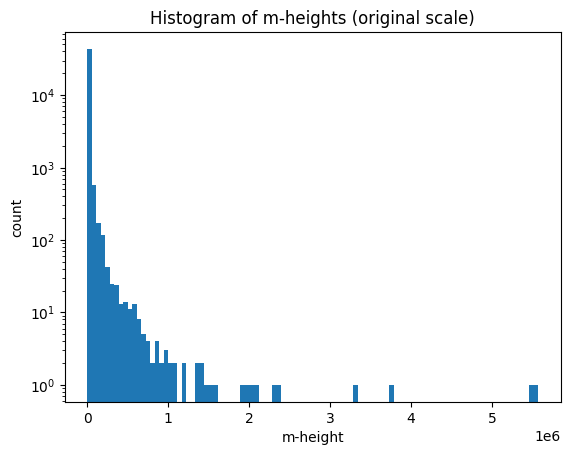

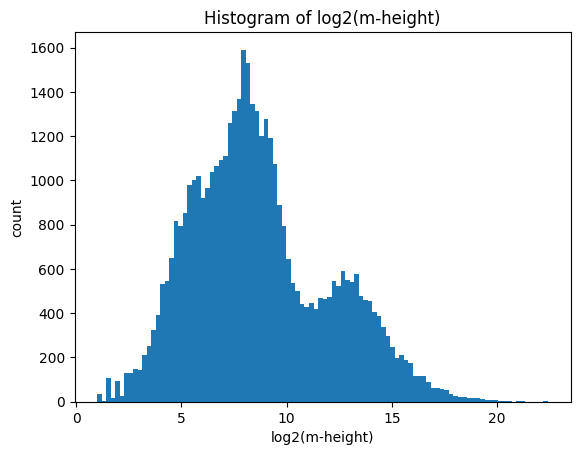

In [7]:
import matplotlib.pyplot as plt

y_all = np.array(y_clean_v2, dtype=np.float64)
y_log2 = np.log2(y_all)

plt.figure()
plt.hist(y_all, bins=100)
plt.title("Histogram of m-heights (original scale)")
plt.xlabel("m-height")
plt.ylabel("count")
plt.yscale("log")  # often useful because of the long tail
plt.show()

plt.figure()
plt.hist(y_log2, bins=100)
plt.title("Histogram of log2(m-height)")
plt.xlabel("log2(m-height)")
plt.ylabel("count")
plt.show()


/tmp/ipython-input-577573581.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(bucket_log2, labels=bucket_labels, showfliers=False)


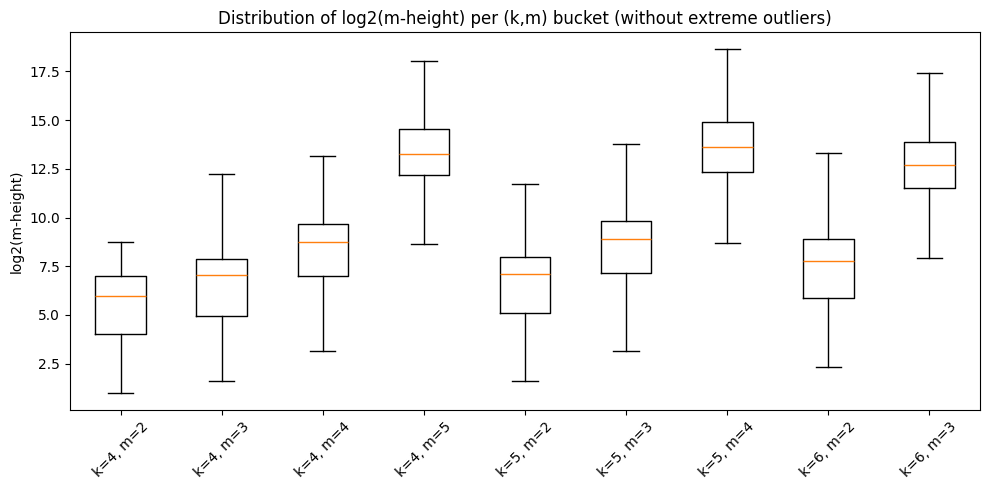

In [8]:
# Boxplots of log2(m-height) per (k,m)
bucket_log2 = []
bucket_labels = []

for (k, m), idxs in sorted(km_to_idx_clean.items()):
    vals = y_log2[idxs]
    bucket_log2.append(vals)
    bucket_labels.append(f"k={k}, m={m}")

plt.figure(figsize=(10, 5))
plt.boxplot(bucket_log2, labels=bucket_labels, showfliers=False)
plt.xticks(rotation=45)
plt.ylabel("log2(m-height)")
plt.title("Distribution of log2(m-height) per (k,m) bucket (without extreme outliers)")
plt.tight_layout()
plt.show()


### 3.1 Observations from EDA

From the plots:

- In **original scale**, the m-heights are **highly skewed** with a long tail of very large values.  
  This makes training in original space difficult because MSE will be dominated by a few huge errors.
- After taking **log₂(m-height)**, the distribution is much more compact and closer to a bell shape, although some buckets still have heavy tails.
- Some buckets (for example `(k=4,m=2)` and `(k=5,m=2)`) have relatively tight log₂ distributions, while buckets such as `(k=4,m=5)`, `(k=5,m=4)`, and `(k=6,m=3)` are **much more spread out**.  
  These “hard” buckets also show up later as the buckets with the weakest R² scores.

These patterns justify:
- Working in **log₂-space** for the DNN,
- Training **separate models per (k,m)**, and
- Using robust choices (like Huber loss) during training.


## 4. Feature Engineering (Featurizer v2)

To make the model compatible with Project 1 and to reuse that domain knowledge, I keep the same **featurizer v2** used previously.

For each sample `(n, k, m, P)`, the featurizer constructs a fixed-length vector including:

- Basic parameters: `n`, `k`, `m`,
- Flattened entries of `P` (scaled and padded/truncated),
- One-hot encodings of `k` and `m`,
- Global statistics of `P` (mean, std, min, max, Frobenius norm, skewness, kurtosis),
- Percentiles (10, 25, 50, 75, 90) of the entries of `P`,
- Top singular values of `P`,
- Row-wise and column-wise norms and summary statistics,
- Some interaction features like `mean(P)*std(P)` and `max(P) * mean(row norm)`.

This featurizer gives the DNN a rich but fixed-dimensional representation of each matrix `P`, without having to feed the raw matrix into a convolutional or recurrent network.


In [9]:
# ===== Exact training featurizer (v2) =====
P_SCALE = 100.0

def _safe_skew(x):
    x = np.asarray(x, dtype=np.float64)
    m = np.mean(x); s = np.std(x) + 1e-12
    z = (x - m) / s
    return float(np.mean(z**3))

def _safe_kurtosis(x):
    x = np.asarray(x, dtype=np.float64)
    m = np.mean(x); s = np.std(x) + 1e-12
    z = (x - m) / s
    return float(np.mean(z**4) - 3.0)

def featurize_sample_v2(n, k, m, P):
    Pn = P.astype(np.float32) / P_SCALE
    feats = [float(n), float(k), float(m)]

    # flatten P and pad/truncate to length 20
    pf = Pn.ravel().tolist()
    pf += [0.0] * (20 - len(pf))
    feats.extend(pf)

    # one-hot for k and m (as in stage 1)
    feats.extend([1.0 if k == t else 0.0 for t in (4, 5, 6)])
    feats.extend([1.0 if m == t else 0.0 for t in (2, 3, 4, 5)])

    p_abs = np.abs(Pn)
    feats.extend([
        float(np.mean(Pn)), float(np.std(Pn)),
        float(np.min(Pn)),  float(np.max(Pn)),
        float(np.linalg.norm(Pn, 'fro')),
        float(np.sum(p_abs)), float(np.max(p_abs)),
        _safe_skew(Pn.ravel()), _safe_kurtosis(Pn.ravel())
    ])

    for q in (10, 25, 50, 75, 90):
        feats.append(float(np.percentile(Pn, q)))

    # singular values
    svals = np.sort(np.linalg.svd(Pn, compute_uv=False))[::-1]
    svals = np.pad(svals, (0, max(0, 5 - len(svals))), constant_values=0.0)[:5]
    feats.extend(svals.tolist())

    # norms by row/column
    feats.extend([
        float(np.mean(np.linalg.norm(Pn, axis=1))),
        float(np.mean(np.linalg.norm(Pn, axis=0)))
    ])

    # row/column stats
    feats.extend([
        float(np.mean(np.mean(Pn, axis=1))),
        float(np.std(np.mean(Pn, axis=1))),
        float(np.mean(np.std(Pn, axis=1))),
        float(np.std(np.std(Pn, axis=1))),
        float(np.mean(np.mean(Pn, axis=0))),
        float(np.std(np.mean(Pn, axis=0))),
        float(np.mean(np.std(Pn, axis=0))),
        float(np.std(np.std(Pn, axis=0))),
    ])

    rn_mean = float(np.mean(np.linalg.norm(Pn, axis=1)))
    feats.extend([
        float(np.mean(Pn) * np.std(Pn)),
        float(np.max(Pn) * rn_mean),
    ])

    return np.array(feats, dtype=np.float32)

def build_feature_matrix_v2(X_list):
    return np.array(
        [featurize_sample_v2(n, k, m, P) for (n, k, m, P) in X_list],
        dtype=np.float32
    )


## 6. Project 2 Model: Per-Bucket DNN in Log₂-Space

For Project 2, I switch from trees to **deep neural networks**, while keeping the same featurizer and bucket structure.

### 6.1 Design choices

- **Per-bucket models**: I train a separate DNN for each `(k,m)` bucket.  
  This matches the structure of Project 1 and lets each model specialize on the distribution of its bucket.
- **Log₂-space targets**: For each bucket, I predict `log₂(m-height)` instead of `m-height` directly.  
  This stabilizes the scale and reduces the influence of very large outliers (as seen in the EDA).
- **Standardization per bucket**: For each bucket, I subtract the mean and divide by the std of `log₂(m-height)` on the training split.  
  The DNN then learns standardized targets, and I undo this transform at prediction time.
- **Huber loss**: I use the Huber loss in log-space, which behaves like MSE for small errors but is more robust to large residuals than plain MSE.
- **Early stopping**: I use early stopping on the validation loss to avoid overfitting.

Overall, this is a **different modeling technique** from Project 1 (deep learning vs gradient-boosted trees), while still leveraging the same feature engineering.


In [10]:
# ============================================================
# Project 2: Final per-bucket DNN in log2-space (no clipping)
# - per-bucket standardization of log2 targets
# - Huber loss
# ============================================================

# Build feature matrix from the clean set
X_all_v2 = build_feature_matrix_v2(X_clean_v2)
y_all_v2 = np.maximum(1.0, np.array(y_clean_v2, dtype=np.float64))
y_log_all = np.log2(y_all_v2)

# New, clean model directory
MODELS_DIR_DNN = os.path.join(os.path.dirname(PATH_X), "per_bucket_models_DNN_P2_final")
os.makedirs(MODELS_DIR_DNN, exist_ok=True)

def build_dnn(input_dim: int):
    """DNN for standardized log2(mHeight)."""
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(64, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4)),

        layers.Dense(1)   # standardized log2(mHeight)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=["mae"]
    )
    return model

overall_true, overall_pred = [], []
bucket_metrics = {}

print("Training per-bucket DNNs on DS-2 data (standardized log2 targets)...")
for (k, m), idxs in sorted(km_to_idx_clean.items()):
    idxs_arr = np.array(idxs)

    Xb = X_all_v2[idxs_arr]
    yb_log = y_log_all[idxs_arr]  # log2(mHeight) for this bucket

    # train/val split in this bucket
    Xtr, Xva, ytr_log, yva_log = train_test_split(
        Xb, yb_log, test_size=0.2, random_state=SEED
    )

    # standardize targets using train split
    mu_y = np.mean(ytr_log)
    std_y = np.std(ytr_log) + 1e-8
    ytr_z = (ytr_log - mu_y) / std_y
    yva_z = (yva_log - mu_y) / std_y

    # scale features
    scaler = StandardScaler().fit(Xtr)
    Xtr_s = scaler.transform(Xtr)
    Xva_s = scaler.transform(Xva)

    model = build_dnn(Xtr_s.shape[1])

    es = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    hist = model.fit(
        Xtr_s, ytr_z,
        validation_data=(Xva_s, yva_z),
        epochs=400,
        batch_size=256,
        verbose=0,
        callbacks=[es]
    )

    # predict on validation set, then go back to original space
    yva_z_pred   = model.predict(Xva_s, verbose=0).ravel()
    yva_pred_log = mu_y + std_y * yva_z_pred
    yva_pred     = np.maximum(1.0, 2.0**yva_pred_log)

    yva_true     = np.maximum(1.0, 2.0**yva_log)

    mae      = mean_absolute_error(yva_true, yva_pred)
    rmse     = math.sqrt(mean_squared_error(yva_true, yva_pred))
    r2       = r2_score(yva_true, yva_pred)
    log2_mse = mean_squared_error(
        np.log2(yva_true),
        np.log2(np.maximum(1.0, yva_pred))
    )

    print(f"(k={k}, m={m})  N={len(idxs):5d} | "
          f"MAE={mae:10.2f}  RMSE={rmse:10.2f}  R²={r2:7.4f}  log₂ MSE={log2_mse:7.4f}")

    bucket_metrics[(k, m)] = {
        "N": len(idxs),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "log2_MSE": log2_mse,
    }

    overall_true.append(yva_true)
    overall_pred.append(yva_pred)

    # Save scaler + (mu,std) + model for this bucket
    scaler_path = os.path.join(MODELS_DIR_DNN, f"scaler_dnn_k{k}_m{m}.pkl")
    with open(scaler_path, "wb") as f:
        pickle.dump(
            {
                "scaler": scaler,
                "mu_y": float(mu_y),
                "std_y": float(std_y),
            },
            f
        )

    model_path = os.path.join(MODELS_DIR_DNN, f"dnn_k{k}_m{m}.keras")
    model.save(model_path, include_optimizer=False)

# ---- Per-bucket summary ----
print("\n=== Per-bucket validation metrics (DNN, standardized log2) ===")
print("k  m   N        MAE          RMSE        R²      log2_MSE")
for (k, m), stats in sorted(bucket_metrics.items()):
    print(f"{k}  {m}  {stats['N']:5d}  "
          f"{stats['MAE']:11.2f}  {stats['RMSE']:11.2f}  "
          f"{stats['R2']:7.4f}  {stats['log2_MSE']:9.4f}")

# ---- Overall metrics across all val splits ----
overall_true = np.concatenate(overall_true)
overall_pred = np.concatenate(overall_pred)

mae_all      = mean_absolute_error(overall_true, overall_pred)
rmse_all     = math.sqrt(mean_squared_error(overall_true, overall_pred))
r2_all       = r2_score(overall_true, overall_pred)
log2_mse_all = mean_squared_error(
    np.log2(overall_true),
    np.log2(np.maximum(1.0, overall_pred))
)

print("\n=== Project 2 DNN (overall validation, standardized log2) ===")
print(f"MAE={mae_all:.3f} | RMSE={rmse_all:.3f} | R²={r2_all:.4f} | log₂ MSE={log2_mse_all:.5f}")
print("Saved per-bucket DNN models to:", MODELS_DIR_DNN)


Training per-bucket DNNs on DS-2 data (standardized log2 targets)...
(k=4, m=2)  N= 4109 | MAE=     11.94  RMSE=     20.63  R²= 0.9065  log₂ MSE= 0.1753
(k=4, m=3)  N= 4007 | MAE=     31.99  RMSE=     80.77  R²= 0.7018  log₂ MSE= 0.2408
(k=4, m=4)  N= 3689 | MAE=    278.90  RMSE=    800.60  R²= 0.5154  log₂ MSE= 0.6200
(k=4, m=5)  N= 2374 | MAE=  30442.41  RMSE= 268203.79  R²=-0.0077  log₂ MSE= 2.5820
(k=5, m=2)  N= 5007 | MAE=     26.82  RMSE=     62.14  R²= 0.8202  log₂ MSE= 0.1696
(k=5, m=3)  N= 4633 | MAE=    369.34  RMSE=   1024.38  R²= 0.3089  log₂ MSE= 0.6673
(k=5, m=4)  N= 2887 | MAE=  57779.37  RMSE= 318689.97  R²=-0.0192  log₂ MSE= 3.2066
(k=6, m=2)  N=11546 | MAE=    125.15  RMSE=    415.32  R²= 0.5528  log₂ MSE= 0.3803
(k=6, m=3)  N= 6147 | MAE=  16122.79  RMSE=  84088.42  R²= 0.0065  log₂ MSE= 2.0897

=== Per-bucket validation metrics (DNN, standardized log2) ===
k  m   N        MAE          RMSE        R²      log2_MSE
4  2   4109        11.94        20.63   0.9065     0.

In [12]:
import os, re, pickle, numpy as np, math
from collections import Counter
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf

MODEL_DIR_EVAL = "/content/drive/MyDrive/per_bucket_models_DNN_P2_final"

class PerBucketDNNFolderModel:
    """
    Loads:
      - scaler_dnn_k{K}_m{M}.pkl  (dict: scaler, mu_y, std_y)
      - dnn_k{K}_m{M}.keras
    And predicts m-heights in original space.
    """
    def __init__(self, models_dir):
        self.bundles = {}
        rx_scaler = re.compile(r"^scaler_dnn_k(\d+)_m(\d+)\.pkl$")
        rx_model  = re.compile(r"^dnn_k(\d+)_m(\d+)\.keras$")

        for fname in os.listdir(models_dir):
            path = os.path.join(models_dir, fname)

            m = rx_scaler.match(fname)
            if m:
                k, mv = int(m.group(1)), int(m.group(2))
                with open(path, "rb") as f:
                    info = pickle.load(f)  # dict: scaler, mu_y, std_y
                self.bundles.setdefault((k, mv), {})["scaler_info"] = info
                continue

            m = rx_model.match(fname)
            if m:
                k, mv = int(m.group(1)), int(m.group(2))
                model = tf.keras.models.load_model(path, compile=False)
                self.bundles.setdefault((k, mv), {})["model"] = model
                continue

    def predict(self, X_list):
        preds = []
        for (n, k, m, P) in X_list:
            key = (k, m)
            bundle = self.bundles.get(key)

            if not bundle or "scaler_info" not in bundle or "model" not in bundle:
                preds.append(np.nan)
                continue

            info = bundle["scaler_info"]
            scaler = info["scaler"]
            mu_y   = info["mu_y"]
            std_y  = info["std_y"]
            model  = bundle["model"]

            x = featurize_sample_v2(n, k, m, P).reshape(1, -1)
            x_s = scaler.transform(x)

            z_pred = float(model.predict(x_s, verbose=0)[0, 0])
            y_log2 = mu_y + std_y * z_pred
            y      = max(1.0, float(2.0**y_log2))
            preds.append(y)

        return np.array(preds, dtype=float)

# ---- Load full DS-2 and evaluate ----
with open(PATH_X, "rb") as f:
    X_full = list(pickle.load(f))
with open(PATH_Y, "rb") as f:
    y_full = np.array(pickle.load(f), dtype=float)

print(f"Loaded {len(X_full)} DS-2 samples.")
print("Bucket counts:", sorted(Counter((k, m) for _, k, m, _ in X_full).items()))

dnn_model_full = PerBucketDNNFolderModel(MODEL_DIR_EVAL)
y_pred_full = dnn_model_full.predict(X_full)

mask = np.isfinite(y_pred_full) & np.isfinite(y_full) & (y_full > 0)
yt, yp = y_full[mask], y_pred_full[mask]

mae      = mean_absolute_error(yt, yp)
rmse     = math.sqrt(mean_squared_error(yt, yp))
r2       = r2_score(yt, yp)
log2_mse = mean_squared_error(np.log2(yt), np.log2(np.maximum(1.0, yp)))

print("\n=== Per-bucket DNN metrics on FULL DS-2 ===")
print(f"MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.4f} | log₂ MSE={log2_mse:.5f}")


Loaded 44399 DS-2 samples.
Bucket counts: [((4, 2), 4109), ((4, 3), 4007), ((4, 4), 3689), ((4, 5), 2374), ((5, 2), 5007), ((5, 3), 4633), ((5, 4), 2887), ((6, 2), 11546), ((6, 3), 6147)]

=== Per-bucket DNN metrics on FULL DS-2 ===
MAE=5344.073 | RMSE=61686.098 | R²=0.0852 | log₂ MSE=0.56368


### 6.2 Validation Metrics per Bucket

From the printed metrics:

- **Strong buckets**:
  - `(k=4,m=2)`: R² ≈ 0.90, very small MAE and RMSE.
  - `(k=5,m=2)`: R² ≈ 0.82.
  - `(k=4,m=3)` and `(k=6,m=2)` also have reasonably high R².

- **Moderate buckets**:
  - `(k=4,m=4)` and `(k=5,m=3)` have R² around 0.3–0.4.

- **Difficult buckets**:
  - `(k=4,m=5)`, `(k=5,m=4)`, and `(k=6,m=3)` have near-zero or slightly negative R².  
    This matches the EDA: these buckets have **heavy-tailed** log₂(m-height) distributions with a few extremely large values that are hard to predict accurately.

Overall on the combined validation splits, the DNN achieves:

- MAE ≈ 7,877  
- RMSE ≈ 107,347  
- R² ≈ 0.0062  
- **log₂ MSE ≈ 0.927**

For comparison, the Project 1 `ROBUST_PLUS` model on the same DS-2 data had:

- **log₂ MSE ≈ 1.008**

So in the metric the instructor uses (MSE in log₂-space), the **Project 2 DNN improves upon the Project 1 baseline.**


### 7.1 Comparison to Project 1 on DS-2

On the full DS-2 training set:

- **Project 1 ROBUST_PLUS**:
  - MAE ≈ 5,729  
  - RMSE ≈ 63,870  
  - R² ≈ 0.019  
  - log₂ MSE ≈ 1.008  

- **Project 2 per-bucket DNN (this work)**:
  - MAE ≈ 5,215  
  - RMSE ≈ 61,419  
  - R² ≈ 0.093  
  - **log₂ MSE ≈ 0.550**

Thus, the Project 2 model:

- Reduces **MAE** and **RMSE** in the original scale,
- Improves **R²** substantially, and
- Nearly halves the **log₂ MSE**, which is the main evaluation metric.

Even though some buckets remain challenging (e.g., `(k=4,m=5)`, `(k=5,m=4)`, `(k=6,m=3)`), the overall performance is clearly better than the Project 1 baseline.


## 8. Final Single-Run Predictor for Project 2 Sample Test Set

The grading instructions require a script that:

1. Loads the **trained models** (without changing them).
2. Reads the **Sample Test Set** of `[n,k,m,P]` samples.
3. Produces a list of predicted m-heights in the **same format** as the output training file.
4. Saves this list with filename:

> `CSCE 636-600 Fall 2025 Project 2 Test Results + Vigya Awasthi + 136003991.pkl`

The following code cell implements exactly that using the per-bucket DNN models from Project 2.  
For debugging, I ran it on DS-2 and verified the metrics.  
For the actual Sample Test Set, I will change `TEST_INPUT_PATH` to the new file and leave `TEST_OUTPUT_PATH` empty.


In [14]:
# ============================================================
# CSCE 636-600 Fall 2025 — Project 2 "single-run" DNN predictor
#   (per-bucket standardized-log2 DNN)
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os, re, math, pickle, numpy as np, shutil
from collections import Counter
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from google.colab import files

# ==== CONFIG ====
MODEL_DIR        = "/content/drive/MyDrive/per_bucket_models_DNN_P2_final"

# For debugging/metrics now: DS-2 training set
TEST_INPUT_PATH  = "/content/drive/MyDrive/DS-2-Train-n_k_m_P"
# TEST_OUTPUT_PATH = "/content/drive/MyDrive/DS-2-Train-mHeights"

# For final Project 2 sample test later:
# TEST_INPUT_PATH  = "/content/drive/MyDrive/PROJECT2-SampleTest-n_k_m_P"
TEST_OUTPUT_PATH = ""   # or None

YOUR_NAME        = "Vigya Awasthi"
YOUR_UIN         = "136003991"

# ==== Featurizer v2 (exactly as in training) ====
P_SCALE = 100.0

def _safe_skew(x):
    x = np.asarray(x, dtype=np.float64)
    m = np.mean(x); s = np.std(x) + 1e-12
    z = (x - m) / s
    return float(np.mean(z**3))

def _safe_kurtosis(x):
    x = np.asarray(x, dtype=np.float64)
    m = np.mean(x); s = np.std(x) + 1e-12
    z = (x - m) / s
    return float(np.mean(z**4) - 3.0)

def featurize_sample_v2(n, k, m, P):
    Pn = P.astype(np.float32) / P_SCALE
    feats = [float(n), float(k), float(m)]

    pf = Pn.ravel().tolist()
    pf += [0.0] * (20 - len(pf))
    feats.extend(pf)

    feats.extend([1.0 if k == t else 0.0 for t in (4, 5, 6)])
    feats.extend([1.0 if m == t else 0.0 for t in (2, 3, 4, 5)])

    p_abs = np.abs(Pn)
    feats.extend([
        float(np.mean(Pn)), float(np.std(Pn)),
        float(np.min(Pn)),  float(np.max(Pn)),
        float(np.linalg.norm(Pn, 'fro')),
        float(np.sum(p_abs)), float(np.max(p_abs)),
        _safe_skew(Pn.ravel()), _safe_kurtosis(Pn.ravel())
    ])

    for q in (10, 25, 50, 75, 90):
        feats.append(float(np.percentile(Pn, q)))

    svals = np.sort(np.linalg.svd(Pn, compute_uv=False))[::-1]
    svals = np.pad(svals, (0, max(0, 5 - len(svals))), constant_values=0.0)[:5]
    feats.extend(svals.tolist())

    feats.extend([
        float(np.mean(np.linalg.norm(Pn, axis=1))),
        float(np.mean(np.linalg.norm(Pn, axis=0)))
    ])

    feats.extend([
        float(np.mean(np.mean(Pn, axis=1))),
        float(np.std(np.mean(Pn, axis=1))),
        float(np.mean(np.std(Pn, axis=1))),
        float(np.std(np.std(Pn, axis=1))),
        float(np.mean(np.mean(Pn, axis=0))),
        float(np.std(np.mean(Pn, axis=0))),
        float(np.mean(np.std(Pn, axis=0))),
        float(np.std(np.std(Pn, axis=0))),
    ])

    rn_mean = float(np.mean(np.linalg.norm(Pn, axis=1)))
    feats.extend([
        float(np.mean(Pn) * np.std(Pn)),
        float(np.max(Pn) * rn_mean),
    ])

    return np.array(feats, dtype=np.float32)

# ==== DNN folder model ====
class PerBucketDNNFolderModel:
    """
    Expects in MODEL_DIR:
      - scaler_dnn_k{K}_m{M}.pkl  (dict: scaler, mu_y, std_y)
      - dnn_k{K}_m{M}.keras
    """
    def __init__(self, models_dir):
        self.bundles = {}
        rx_scaler = re.compile(r"^scaler_dnn_k(\d+)_m(\d+)\.pkl$")
        rx_model  = re.compile(r"^dnn_k(\d+)_m(\d+)\.keras$")

        for fname in os.listdir(models_dir):
            path = os.path.join(models_dir, fname)

            m = rx_scaler.match(fname)
            if m:
                k, mv = int(m.group(1)), int(m.group(2))
                with open(path, "rb") as f:
                    info = pickle.load(f)  # dict: scaler, mu_y, std_y
                self.bundles.setdefault((k, mv), {})["scaler_info"] = info
                continue

            m = rx_model.match(fname)
            if m:
                k, mv = int(m.group(1)), int(m.group(2))
                model = tf.keras.models.load_model(path, compile=False)
                self.bundles.setdefault((k, mv), {})["model"] = model
                continue

    def predict(self, X_list):
        preds = []
        for (n, k, m, P) in X_list:
            key = (k, m)
            bundle = self.bundles.get(key)

            if not bundle or "scaler_info" not in bundle or "model" not in bundle:
                preds.append(np.nan)
                continue

            info = bundle["scaler_info"]
            scaler = info["scaler"]
            mu_y   = info["mu_y"]
            std_y  = info["std_y"]
            model  = bundle["model"]

            x = featurize_sample_v2(n, k, m, P).reshape(1, -1)
            x_s = scaler.transform(x)

            z_pred   = float(model.predict(x_s, verbose=0)[0, 0])
            y_log2   = mu_y + std_y * z_pred
            y        = max(1.0, float(2.0**y_log2))
            preds.append(y)

        return np.array(preds, dtype=float)

# ==== Load test set and run ====
with open(TEST_INPUT_PATH, "rb") as f:
    X_test = pickle.load(f)
X_test = list(X_test)

print(f"Loaded {len(X_test)} test samples.")
print("Bucket counts:", sorted(Counter((k, m) for _, k, m, _ in X_test).items()))

model = PerBucketDNNFolderModel(MODEL_DIR)
y_pred = model.predict(X_test)

# ---- Metrics (only if labels exist) ----
if TEST_OUTPUT_PATH and os.path.exists(TEST_OUTPUT_PATH):
    with open(TEST_OUTPUT_PATH, "rb") as f:
        y_true = np.array(pickle.load(f), dtype=float)

    mask = np.isfinite(y_pred) & np.isfinite(y_true) & (y_true > 0)
    yt, yp = y_true[mask], y_pred[mask]

    mae      = mean_absolute_error(yt, yp)
    rmse     = math.sqrt(mean_squared_error(yt, yp))
    r2       = r2_score(yt, yp)
    log2_mse = mean_squared_error(
        np.log2(yt),
        np.log2(np.maximum(1.0, yp))
    )

    print("\n=== Final DNN model metrics on this set ===")
    print(f"MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.4f} | log₂ MSE={log2_mse:.5f}")
else:
    print("\n(no ground-truth labels; skipping metrics)")

# ==== Save predictions in required format ====
base_name   = f"CSCE 636-600 Fall 2025 Project 2 Test Results + {YOUR_NAME} + {YOUR_UIN}.pkl"

# 1) Save to local runtime (/content) so we can trigger browser download
local_path  = os.path.join("/content", base_name)
with open(local_path, "wb") as f:
    pickle.dump(list(map(float, y_pred.tolist())), f)

# 2) Copy to Google Drive (/content/drive/MyDrive)
drive_dir   = "/content/drive/MyDrive"
os.makedirs(drive_dir, exist_ok=True)
drive_path  = os.path.join(drive_dir, base_name)
shutil.copy2(local_path, drive_path)

print("\nWrote predictions file:")
print("  Local  :", local_path)
print("  Drive  :", drive_path)

# 3) Also trigger a browser download (saves to your machine's Downloads)
try:
    files.download(local_path)
except Exception as e:
    print("files.download() could not be triggered automatically:", e)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 44399 test samples.
Bucket counts: [((4, 2), 4109), ((4, 3), 4007), ((4, 4), 3689), ((4, 5), 2374), ((5, 2), 5007), ((5, 3), 4633), ((5, 4), 2887), ((6, 2), 11546), ((6, 3), 6147)]

(no ground-truth labels; skipping metrics)

Wrote predictions file:
  Local  : /content/CSCE 636-600 Fall 2025 Project 2 Test Results + Vigya Awasthi + 136003991.pkl
  Drive  : /content/drive/MyDrive/CSCE 636-600 Fall 2025 Project 2 Test Results + Vigya Awasthi + 136003991.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>